# CNN From Scratch vs. Transfer Learning — CIFAR-10
**Roll No: `23DCS002`**

This notebook implements:
1. A custom CNN (3–4 conv layers) trained from scratch on CIFAR-10
2. A fine-tuned ResNet-18 (transfer learning) on the same data
3. Full comparison: accuracy, loss curves, params, training time, confusion matrices
4. First-layer kernel visualization for both models
5. Full evaluation metrics: accuracy, precision/recall/F1 (macro + per-class), AUC-ROC (OvR), convergence speed
6. Experiment tracking with Weights & Biases (WandB)



## 1. Setup: install & import libraries

In [ ]:
!pip install -q wandb torchmetrics scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.8 MB/s eta 0:00:00


In [ ]:
import os, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                              accuracy_score, roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. WandB login

Get a free API key from https://wandb.ai/authorize, then run the cell below and paste it when prompted.


In [ ]:
!pip install -q wandb

In [ ]:
import wandb

wandb.login()

PROJECT_NAME = "cnn-vs-transfer-cifar10"


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


## 3. Config

`SUBSET_FRACTION` lets you train on a fraction of CIFAR-10 to keep runtime reasonable
(the assignment explicitly allows this). Set it to `1.0` to use the full dataset.


In [ ]:
CONFIG = dict(
    subset_fraction   = 0.4,
    val_fraction      = 0.1,
    batch_size        = 128,
    num_epochs_custom = 15,
    num_epochs_pretrained = 8,
    lr_custom         = 1e-3,
    lr_pretrained     = 1e-4,
    num_classes       = 10,
    val_acc_threshold = 0.60,
    image_size_pretrained = 224,
)
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


## 4. Data loading

In [ ]:
mean32, std32 = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
transform_custom_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean32, std32),
])
transform_custom_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean32, std32),
])

mean_in, std_in = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
transform_pre_train = transforms.Compose([
    transforms.Resize(CONFIG["image_size_pretrained"]),
    transforms.RandomCrop(CONFIG["image_size_pretrained"], padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean_in, std_in),
])
transform_pre_test = transforms.Compose([
    transforms.Resize(CONFIG["image_size_pretrained"]),
    transforms.ToTensor(),
    transforms.Normalize(mean_in, std_in),
])

full_train_raw = datasets.CIFAR10(root="./data", train=True, download=True)
full_test_raw  = datasets.CIFAR10(root="./data", train=False, download=True)


n_total = len(full_train_raw)
n_subset = int(CONFIG["subset_fraction"] * n_total)
rng = np.random.default_rng(SEED)
subset_idx = rng.choice(n_total, size=n_subset, replace=False)
n_val = int(CONFIG["val_fraction"] * n_subset)
val_idx, train_idx = subset_idx[:n_val], subset_idx[n_val:]

print(f"Train images: {len(train_idx)} | Val images: {len(val_idx)} | Test images: {len(full_test_raw)}")


100%|██████████| 170M/170M [23:11<00:00, 123kB/s]


Train images: 18000 | Val images: 2000 | Test images: 10000


In [ ]:
def make_loaders(transform_train, transform_test, batch_size):
    train_ds_full = datasets.CIFAR10(root="./data", train=True, transform=transform_train)
    val_ds_full   = datasets.CIFAR10(root="./data", train=True, transform=transform_test)
    test_ds       = datasets.CIFAR10(root="./data", train=False, transform=transform_test)

    train_ds = Subset(train_ds_full, train_idx)
    val_ds   = Subset(val_ds_full, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

train_loader_c, val_loader_c, test_loader_c = make_loaders(transform_custom_train, transform_custom_test, CONFIG["batch_size"])
train_loader_p, val_loader_p, test_loader_p = make_loaders(transform_pre_train, transform_pre_test, CONFIG["batch_size"])


## 5. Custom CNN (from scratch)

In [ ]:
class CustomCNN(nn.Module):
    """4 conv layers -> BN -> ReLU -> pool, then a small classifier head."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

custom_model = CustomCNN(CONFIG["num_classes"]).to(device)
n_params_custom = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)
print(f"Custom CNN trainable params: {n_params_custom:,}")


Custom CNN trainable params: 768,650


## 6. Pretrained model (ResNet-18, fine-tuned)

In [ ]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, CONFIG["num_classes"])
pretrained_model = pretrained_model.to(device)

n_params_pretrained = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"ResNet-18 trainable params (fine-tuning all layers): {n_params_pretrained:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 50.0MB/s]


ResNet-18 trainable params (fine-tuning all layers): 11,181,642


## 7. Generic training loop (with WandB logging + convergence tracking)

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs, lr, run_name, val_acc_threshold):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    run = wandb.init(project=PROJECT_NAME, name=run_name, reinit=True,
                      config={**CONFIG, "lr": lr, "num_epochs": num_epochs, "model": run_name})

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    epoch_to_threshold = None
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)
        val_loss = v_loss / v_total
        val_acc = v_correct / v_total
        scheduler.step()

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        if epoch_to_threshold is None and val_acc >= val_acc_threshold:
            epoch_to_threshold = epoch

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        wandb.log({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                   "val_loss": val_loss, "val_acc": val_acc})
        print(f"[{run_name}] Epoch {epoch}/{num_epochs} | train_loss {train_loss:.4f} "
              f"train_acc {train_acc:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

    train_time = time.time() - start_time
    model.load_state_dict(best_state)

    wandb.summary["training_time_sec"] = train_time
    wandb.summary["epochs_to_reach_threshold"] = epoch_to_threshold if epoch_to_threshold else -1
    wandb.summary["best_val_acc"] = best_val_acc

    return model, history, train_time, epoch_to_threshold, run


## 8. Train the custom CNN

In [ ]:
custom_model, hist_custom, time_custom, conv_epoch_custom, run_custom = train_model(
    custom_model, train_loader_c, val_loader_c,
    num_epochs=CONFIG["num_epochs_custom"], lr=CONFIG["lr_custom"],
    run_name="custom_cnn_cifar10", val_acc_threshold=CONFIG["val_acc_threshold"]
)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[custom_cnn_cifar10] Epoch 1/15 | train_loss 1.7146 train_acc 0.3621 | val_loss 1.4968 val_acc 0.4400
[custom_cnn_cifar10] Epoch 2/15 | train_loss 1.3798 train_acc 0.4954 | val_loss 1.4371 val_acc 0.4730
[custom_cnn_cifar10] Epoch 3/15 | train_loss 1.2122 train_acc 0.5604 | val_loss 1.1227 val_acc 0.5970
[custom_cnn_cifar10] Epoch 4/15 | train_loss 1.0977 train_acc 0.6072 | val_loss 1.0092 val_acc 0.6455
[custom_cnn_cifar10] Epoch 5/15 | train_loss 1.0089 train_acc 0.6414 | val_loss 1.0027 val_acc 0.6275
[custom_cnn_cifar10] Epoch 6/15 | train_loss 0.9324 train_acc 0.6691 | val_loss 0.8660 val_acc 0.6845
[custom_cnn_cifar10] Epoch 7/15 | train_loss 0.8737 train_acc 0.6911 | val_loss 0.8982 val_acc 0.6870
[custom_cnn_cifar10] Epoch 8/15 | train_loss 0.8324 train_acc 0.7053 | val_loss 0.7877 val_acc 0.7110
[custom_cnn_cifar10] Epoch 9/15 | train_loss 0.7855 train_acc 0.7201 | val_loss 0.7601 val_acc 0.7385
[custom_cnn_cifar10] Epoch 10/15 | train_loss 0.7451 train_acc 0.7396 | val_loss 0

## 9. Fine-tune the pretrained ResNet-18

In [ ]:
pretrained_model, hist_pre, time_pre, conv_epoch_pre, run_pre = train_model(
    pretrained_model, train_loader_p, val_loader_p,
    num_epochs=CONFIG["num_epochs_pretrained"], lr=CONFIG["lr_pretrained"],
    run_name="resnet18_finetune_cifar10", val_acc_threshold=CONFIG["val_acc_threshold"]
)


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▄▅▆▆▇▇▇▇▇████
train_loss,█▆▅▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▂▄▅▅▆▆▇▇█▇████
val_loss,██▅▄▄▃▃▂▂▁▂▁▁▁▁
best_val_acc,0.7795
epoch,15
epochs_to_reach_threshold,4
train_acc,0.77889
train_loss,0.62586
training_time_sec,133.40343


[resnet18_finetune_cifar10] Epoch 1/8 | train_loss 0.5423 train_acc 0.8249 | val_loss 0.2638 val_acc 0.9120
[resnet18_finetune_cifar10] Epoch 2/8 | train_loss 0.1876 train_acc 0.9398 | val_loss 0.2158 val_acc 0.9235
[resnet18_finetune_cifar10] Epoch 3/8 | train_loss 0.1081 train_acc 0.9687 | val_loss 0.1963 val_acc 0.9290
[resnet18_finetune_cifar10] Epoch 4/8 | train_loss 0.0627 train_acc 0.9838 | val_loss 0.1742 val_acc 0.9435
[resnet18_finetune_cifar10] Epoch 5/8 | train_loss 0.0411 train_acc 0.9907 | val_loss 0.1657 val_acc 0.9395
[resnet18_finetune_cifar10] Epoch 6/8 | train_loss 0.0254 train_acc 0.9959 | val_loss 0.1544 val_acc 0.9470
[resnet18_finetune_cifar10] Epoch 7/8 | train_loss 0.0197 train_acc 0.9973 | val_loss 0.1524 val_acc 0.9490
[resnet18_finetune_cifar10] Epoch 8/8 | train_loss 0.0168 train_acc 0.9979 | val_loss 0.1533 val_acc 0.9490


## 10. Loss / accuracy curves

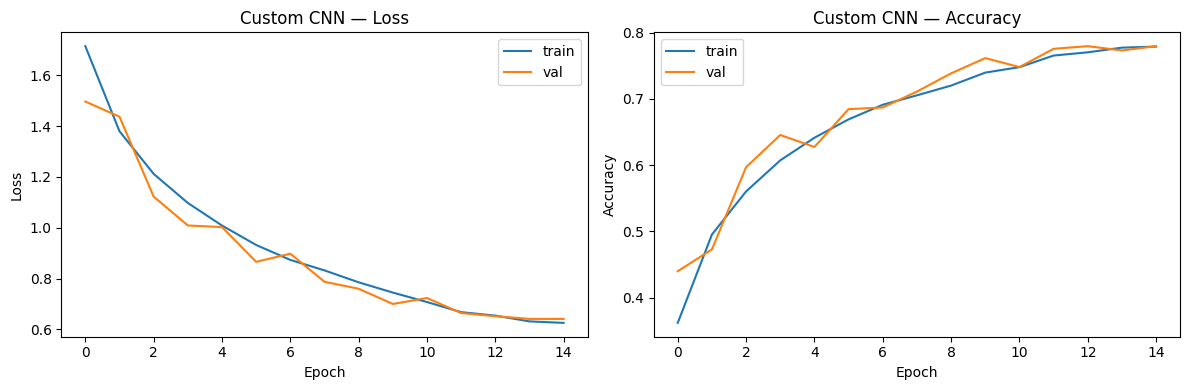

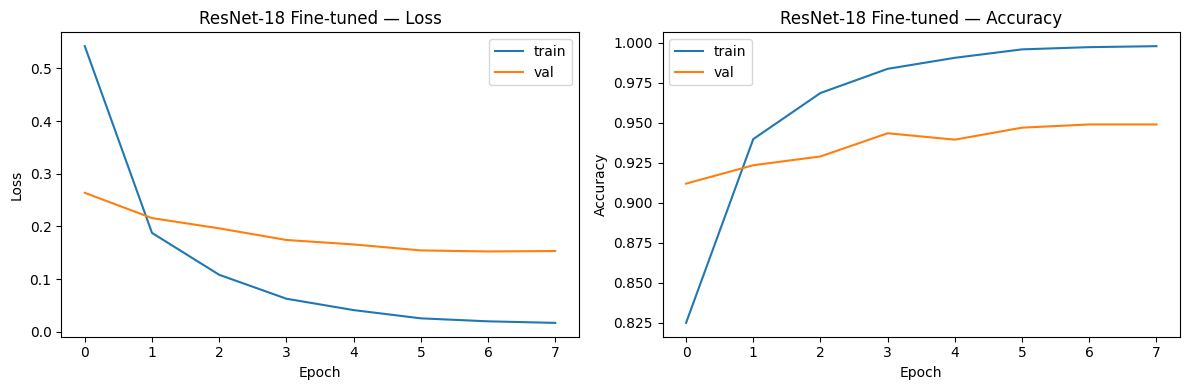

In [ ]:
def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}_curves.png", dpi=150)
    plt.show()

plot_curves(hist_custom, "Custom CNN")
plot_curves(hist_pre, "ResNet-18 Fine-tuned")


## 11. Full evaluation (accuracy, precision/recall/F1, confusion matrix, AUC-ROC)

In [ ]:
@torch.no_grad()
def evaluate(model, loader, run, model_tag):
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(1)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_probs.extend(probs.tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)


    acc = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    y_bin = label_binarize(
        all_labels,
        classes=list(range(CONFIG["num_classes"]))
    )

    auc_macro = roc_auc_score(
        y_bin,
        all_probs,
        average="macro",
        multi_class="ovr"
    )

    auc_per_class = roc_auc_score(
        y_bin,
        all_probs,
        average=None,
        multi_class="ovr"
    )

    cm = confusion_matrix(all_labels, all_preds)


    print(f"\n=== {model_tag} — Test set metrics ===")
    print(f"Accuracy: {acc:.4f}")
    print(
        f"Macro Precision: {precision_macro:.4f} | "
        f"Macro Recall: {recall_macro:.4f} | "
        f"Macro F1: {f1_macro:.4f}"
    )
    print(f"Macro AUC-ROC (OvR): {auc_macro:.4f}")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=CLASSES,
            zero_division=0
        )
    )


    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ax=ax
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_tag} — Confusion Matrix")

    plt.tight_layout()

    cm_path = f"{model_tag.replace(' ', '_')}_confusion_matrix.png"

    plt.savefig(cm_path, dpi=150)
    plt.show()
    plt.close()

    # Store metrics
    metrics = {
        "test_accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "auc_roc_macro": auc_macro,
    }

    for i, cls in enumerate(CLASSES):
        metrics[f"precision_{cls}"] = precision_pc[i]
        metrics[f"recall_{cls}"] = recall_pc[i]
        metrics[f"f1_{cls}"] = f1_pc[i]
        metrics[f"auc_roc_{cls}"] = auc_per_class[i]


    if run is not None:
        run.log({
            **metrics,
            "confusion_matrix_img": wandb.Image(cm_path)
        })


    return metrics, cm


=== Custom CNN — Test set metrics ===
Accuracy: 0.7617
Macro Precision: 0.7629 | Macro Recall: 0.7617 | Macro F1: 0.7614
Macro AUC-ROC (OvR): 0.9715
              precision    recall  f1-score   support

       plane       0.77      0.78      0.77      1000
         car       0.92      0.83      0.88      1000
        bird       0.68      0.65      0.66      1000
         cat       0.57      0.59      0.58      1000
        deer       0.73      0.73      0.73      1000
         dog       0.69      0.64      0.66      1000
        frog       0.77      0.85      0.81      1000
       horse       0.82      0.79      0.80      1000
        ship       0.87      0.87      0.87      1000
       truck       0.81      0.89      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



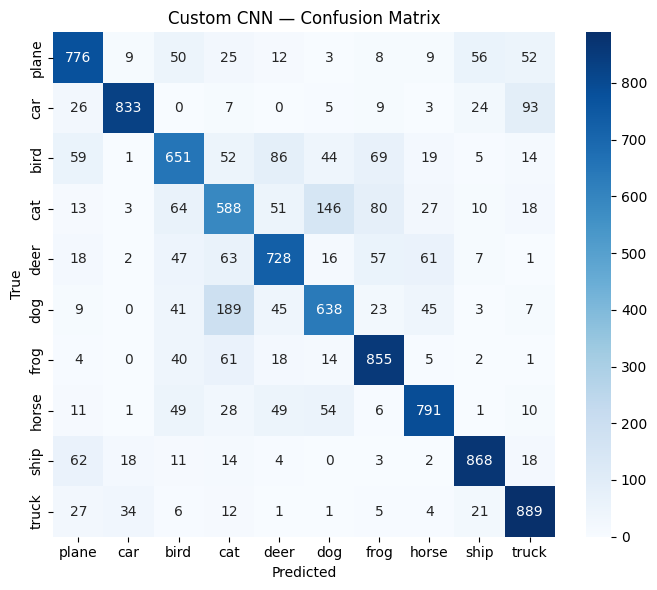

auc_roc_bird,▁
auc_roc_car,▁
auc_roc_cat,▁
auc_roc_deer,▁
auc_roc_dog,▁
auc_roc_frog,▁
auc_roc_horse,▁
auc_roc_macro,▁
auc_roc_plane,▁
auc_roc_ship,▁
+35,...



=== ResNet-18 Fine-tuned — Test set metrics ===
Accuracy: 0.9419
Macro Precision: 0.9420 | Macro Recall: 0.9419 | Macro F1: 0.9418
Macro AUC-ROC (OvR): 0.9975
              precision    recall  f1-score   support

       plane       0.94      0.95      0.94      1000
         car       0.97      0.96      0.97      1000
        bird       0.94      0.92      0.93      1000
         cat       0.89      0.86      0.88      1000
        deer       0.94      0.95      0.95      1000
         dog       0.89      0.92      0.91      1000
        frog       0.95      0.97      0.96      1000
       horse       0.98      0.95      0.96      1000
        ship       0.96      0.96      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



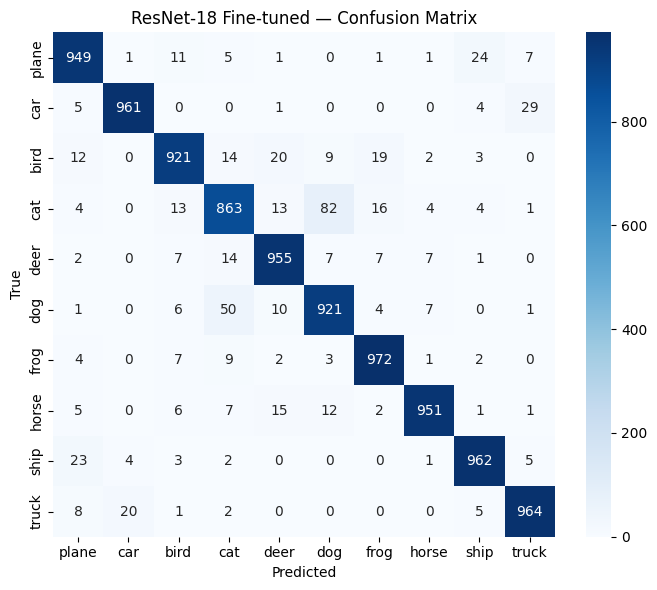

auc_roc_bird,▁
auc_roc_car,▁
auc_roc_cat,▁
auc_roc_deer,▁
auc_roc_dog,▁
auc_roc_frog,▁
auc_roc_horse,▁
auc_roc_macro,▁
auc_roc_plane,▁
auc_roc_ship,▁
+35,...


In [ ]:

run_custom = wandb.init(
    project="cifar10-classification",
    name="Custom-CNN-Evaluation"
)

metrics_custom, cm_custom = evaluate(
    custom_model,
    test_loader_c,
    run_custom,
    "Custom CNN"
)

run_custom.finish()


run_pre = wandb.init(
    project="cifar10-classification",
    name="ResNet18-Fine-tuned-Evaluation"
)

metrics_pre, cm_pre = evaluate(
    pretrained_model,
    test_loader_p,
    run_pre,
    "ResNet-18 Fine-tuned"
)


run_pre.finish()

## 12. Kernel visualization (first convolutional layer)

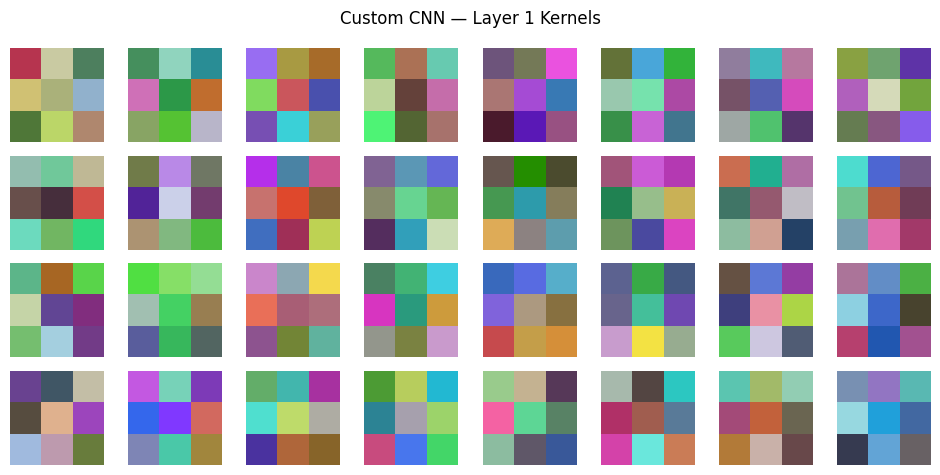

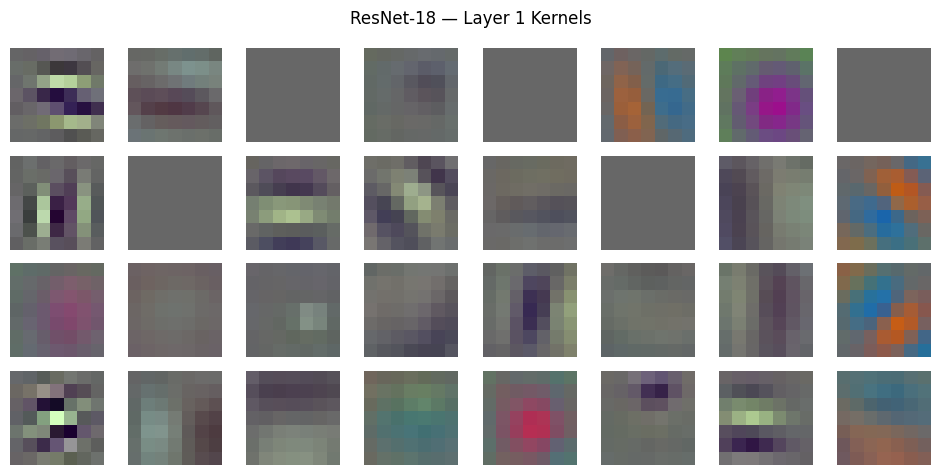

In [ ]:
def visualize_first_layer_kernels(model, layer, title, n_kernels=32):
    weights = layer.weight.data.clone().cpu()
    weights = weights[:n_kernels]

    w_min, w_max = weights.min(), weights.max()
    weights = (weights - w_min) / (w_max - w_min + 1e-8)

    n = weights.shape[0]
    ncols = 8
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.2))
    for i, ax in enumerate(axes.flat):
        if i < n:
            kernel = weights[i]
            if kernel.shape[0] == 3:
                ax.imshow(kernel.permute(1, 2, 0).numpy())
            else:
                ax.imshow(kernel[0].numpy(), cmap="gray")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}_kernels.png", dpi=150)
    plt.show()

visualize_first_layer_kernels(custom_model, custom_model.conv1, "Custom CNN — Layer 1 Kernels")
visualize_first_layer_kernels(pretrained_model, pretrained_model.conv1, "ResNet-18 — Layer 1 Kernels", n_kernels=32)


**Comment on kernel patterns (edit after inspecting your own plots):**
The custom CNN's first-layer kernels, trained from random initialization on a small
dataset, typically look noisier and more color-blob-like, with fewer kernels resembling
clean edge/orientation detectors. The pretrained ResNet-18 kernels, learned on the much
larger and more diverse ImageNet corpus, generally show classic Gabor-like edge, color-opponent,
and blob detectors — a well known signature of models trained on large datasets with enough
capacity and data to learn general-purpose low-level filters.


## 13. Comparison table & discussion

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro AUC-ROC",
               "Trainable Params", "Training Time (s)", "Epochs to reach val_acc>=%.2f" % CONFIG["val_acc_threshold"]],
    "Custom CNN": [metrics_custom["test_accuracy"], metrics_custom["precision_macro"],
                   metrics_custom["recall_macro"], metrics_custom["f1_macro"], metrics_custom["auc_roc_macro"],
                   n_params_custom, round(time_custom, 1), conv_epoch_custom],
    "ResNet-18 (fine-tuned)": [metrics_pre["test_accuracy"], metrics_pre["precision_macro"],
                               metrics_pre["recall_macro"], metrics_pre["f1_macro"], metrics_pre["auc_roc_macro"],
                               n_params_pretrained, round(time_pre, 1), conv_epoch_pre],
})
comparison


,Metric,Custom CNN,ResNet-18 (fine-tuned)
0,Test Accuracy,0.761700,9.419000e-01
1,Macro Precision,0.762880,9.420214e-01
2,Macro Recall,0.761700,9.419000e-01
3,Macro F1,0.761420,9.418492e-01
4,Macro AUC-ROC,0.971459,9.975241e-01
5,Trainable Params,768650.000000,1.118164e+07
6,Training Time (s),133.400000,5.772000e+02
7,Epochs to reach val_acc>=0.60,4.000000,1.000000e+00
